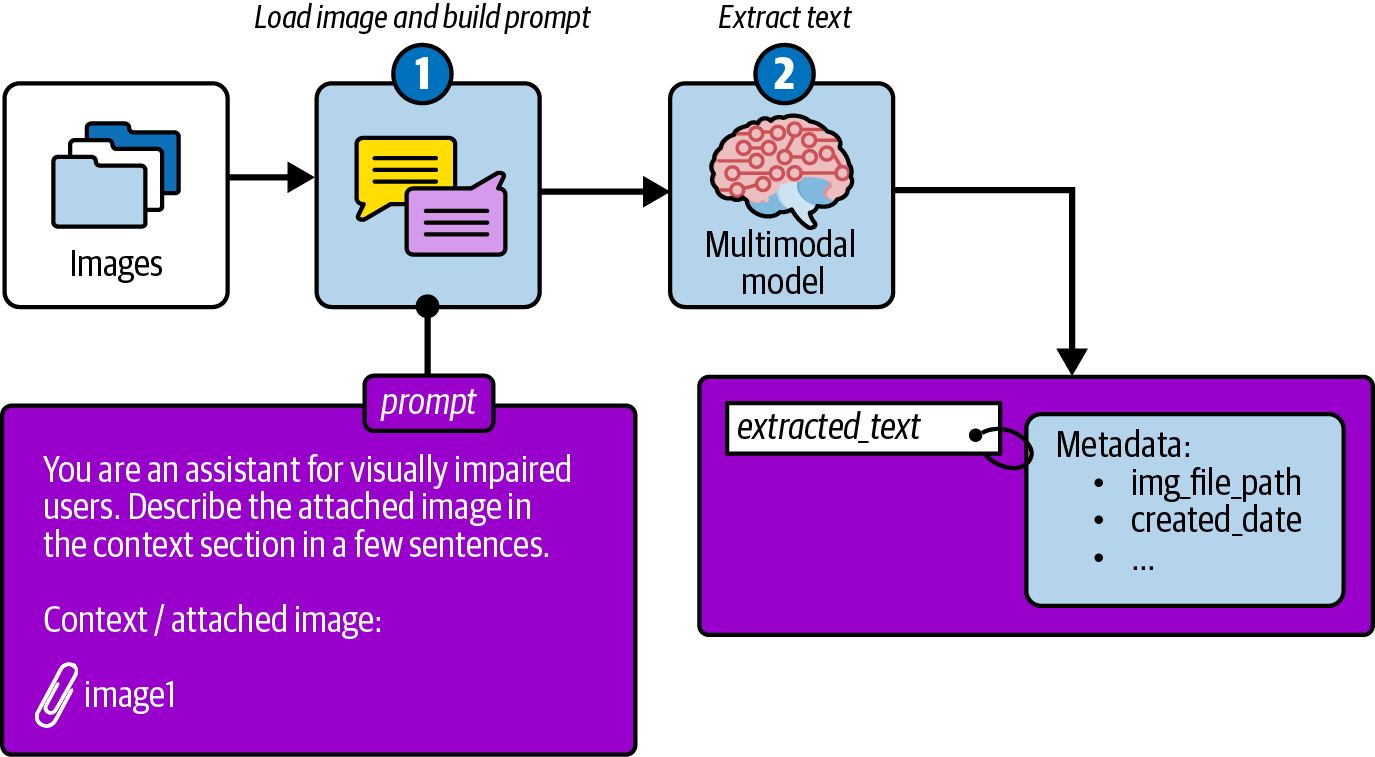

In [1]:
from IPython.display import Image, display
display(Image(filename="../images/18.png", width=500, height=500))

In [ ]:
import os
import base64
from openai import OpenAI

image_path = "../datasets/images/vietnam.png"

# Initialize the OpenAI client
client = OpenAI()

with open(image_path, "rb") as image_file:
    base64_image = base64.b64encode(image_file.read()).decode("utf-8")

    prompt = (
        "You are an assistant for visually impaired users. "
        "Describe the image in detail."
    )

    response = client.chat.completions.create(
        model="gpt-5-mini",
        messages=[
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": prompt},
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": (
                                f"data:image/jpeg;base64,"
                                f"{base64_image}"
                            ),
                        },
                    },
                ],
            }
        ],
        max_tokens=150,
    )

    content = response.choices[0].message.content